# Photon Injection Validation Suite

Consolidated physics tests for monochromatic photon injection in spectroxide.
Tests the PDE solver against analytic Green's functions, energy/number conservation,
soft-photon equivalence to heat injection, linearity, DC/BR absorption, and grid convergence.

**Sections:**
1. Soft-photon equivalence to heat injection
2. Energy conservation budget
3. Photon number conservation (DC/BR off)
4. Linearity in ΔN/N
5. PDE vs GF spectral comparison
6. DC/BR optical depth cross-check
7. Grid convergence at low x_inj
8. z_h transition shape
9. Summary

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

from spectroxide import (
    ALPHA_RHO, X_BALANCED, KAPPA_C, G2_PLANCK, G3_PLANCK,
    x_c_dc, x_c_br, x_c,
    photon_survival_probability,
    greens_function_photon, greens_function,
    mu_from_photon_injection,
    mu_shape, y_shape, temperature_shift_shape, g_bb, planck,
    j_bb_star, j_mu, j_y,
    delta_n_to_delta_I,
    decompose_distortion,
    strip_gbb,
    apply_style,
)

from spectroxide.solver import solve

apply_style()

# --- Helper functions ---
# All PDE runs use PRODUCTION quality defaults (4000 pts, production grid,
# dtau_max_photon_source=1.0) unless explicitly overridden.

def run_pde_photon(x_inj, z_h, delta_n_over_n=1e-5, sigma_x=None,
                   z_end=500, n_points=None, timeout=600,
                   no_dcbr=False):
    """Run PDE solver for monochromatic photon injection.
    Returns (x, delta_n, mu, y) from the solver."""
    if sigma_x is None:
        sigma_x = x_inj * 0.05
    sigma_z = max(z_h * 0.04, 100)
    z_start = z_h + 7 * sigma_z

    sweep_kwargs = dict(
        injection={
            'type': 'monochromatic_photon',
            'x_inj': x_inj,
            'delta_n_over_n': delta_n_over_n,
            'z_h': z_h,
            'sigma_x': sigma_x,
        },
        z_start=z_start,
        z_end=z_end,
        number_conserving=False,
        nc_z_min=0,
        no_dcbr=no_dcbr,
        timeout=timeout,
    )
    if n_points is not None:
        sweep_kwargs['n_points'] = n_points
    result = solve(**sweep_kwargs)
    return np.asarray(result.x), np.asarray(result.delta_n), result.mu, result.y


def run_pde_heat(z_h, delta_rho, z_end=500, n_points=None,
                 timeout=600):
    """Run PDE solver for single-burst heat injection.
    Returns (x, delta_n, mu, y) from the solver."""
    sigma_z = max(z_h * 0.04, 100)
    z_start = z_h + 7 * sigma_z

    sweep_kwargs = dict(
        injection={
            'type': 'single_burst',
            'z_h': z_h,
        },
        delta_rho=delta_rho,
        z_start=z_start,
        z_end=z_end,
        number_conserving=False,
        nc_z_min=0,
        timeout=timeout,
    )
    if n_points is not None:
        sweep_kwargs['n_points'] = n_points
    result = solve(**sweep_kwargs)
    return np.asarray(result.x), np.asarray(result.delta_n), result.mu, result.y


def rms_percent(x1, dn1, x2, dn2, x_lo=1.0, x_hi=15.0):
    """RMS % difference between two spectra on a common grid.
    Normalized to max|dn2| in [x_lo, x_hi]."""
    mask = (x1 >= x_lo) & (x1 <= x_hi)
    if not np.any(mask):
        return np.inf
    dn2_interp = np.interp(x1, x2, dn2)
    diff = dn1[mask] - dn2_interp[mask]
    norm = np.max(np.abs(dn2_interp[mask]))
    if norm == 0:
        return np.inf
    return 100 * np.sqrt(np.mean(diff**2)) / norm


# Collect results for summary table
summary = []
print("Using PRODUCTION quality defaults for all PDE runs.")

Using PRODUCTION quality defaults for all PDE runs.


## Section 1: Energy Routing — PDE μ vs GF μ in the μ-era

Compare PDE μ (from NC-stripped decomposition) against `mu_from_photon_injection` at
several $x_\mathrm{inj}$ values, all at $z_h = 3 \times 10^5$ (deep μ-era).

**Why μ-era only**: In the transition era ($z_h \sim 10^5$), the GF prediction for μ is
tiny ($J_\mu \to 0$), but the PDE produces a real distortion that decomposes partly as μ.
This isn't a code bug — it's a regime where the μ/y decomposition is ill-conditioned.

**Linearity constraint**: Full absorption ($P_s \ll 1$) requires $x_\mathrm{inj} \ll x_c \approx 0.005$,
but at such low $x_\mathrm{inj}$ the local perturbation $\Delta n / n_\mathrm{pl} \gg 1$
(nonlinear). We use $x_\mathrm{inj} \geq 0.1$ where $P_s > 0.95$ (mostly surviving).

In [2]:
# Section 1: Energy routing — PDE mu vs GF mu_from_photon_injection
# Test at various (x_inj, z_h) in the mu-era where mu is well-defined.
# Transition era (z_h=1e5) excluded: GF mu is tiny there (J_mu ~ 0)
# while PDE produces real distortion that decomposes partly as mu.

dn_over_n_s1 = 1e-5
test_cases_s1 = [
    # (x_inj, z_h, description)
    (0.1,  3e5, 'soft, mu-era'),
    (0.5,  3e5, 'moderate, mu-era'),
    (1.0,  3e5, 'near x_c, mu-era'),
    (5.0,  3e5, 'hard, mu-era'),
]

results_s1 = []

for x_i, z_i, desc in test_cases_s1:
    ps = float(photon_survival_probability(np.array([x_i]), z_i)[0])
    mu_gf = mu_from_photon_injection(x_i, z_i, dn_over_n_s1)
    
    print(f"x_inj={x_i}, z_h={z_i:.0e} ({desc}): P_s={ps:.4f}, mu_GF={mu_gf:.4e}")
    
    x_pde, dn_pde, _, _ = run_pde_photon(x_i, z_i, delta_n_over_n=dn_over_n_s1,
                                           timeout=900)
    dn_nc, _ = strip_gbb(x_pde, dn_pde)
    decomp = decompose_distortion(x_pde, dn_nc)
    mu_pde = decomp['mu']
    
    dev = abs(mu_pde / mu_gf - 1) * 100 if abs(mu_gf) > 1e-20 else float('inf')
    print(f"  mu_PDE={mu_pde:.4e}, dev={dev:.1f}%")
    
    results_s1.append({
        'x_inj': x_i, 'z_h': z_i, 'desc': desc,
        'ps': ps, 'mu_gf': mu_gf, 'mu_pde': mu_pde, 'dev': dev,
    })

# Pass/fail: PDE mu should agree with GF within 15%
# (Skip x_inj near X_BALANCED ~ 3.6 where GF has known issues)
testable = [r for r in results_s1 if abs(r['x_inj'] - X_BALANCED) > 0.5]
max_dev = max(r['dev'] for r in testable) if testable else float('inf')
s1_pass = max_dev < 15.0

summary.append({
    'test': 'Energy routing: PDE mu vs GF',
    'metric': f'max dev = {max_dev:.1f}%',
    'pass': s1_pass,
})

print(f"\n{'x_inj':>6}  {'z_h':>8}  {'P_s':>6}  {'mu_GF':>12}  {'mu_PDE':>12}  {'dev%':>8}")
for r in results_s1:
    print(f"{r['x_inj']:6.2f}  {r['z_h']:8.0e}  {r['ps']:6.4f}  "
          f"{r['mu_gf']:12.4e}  {r['mu_pde']:12.4e}  {r['dev']:7.1f}%")

# Also document the linearity limit
print("\n--- Linearity limit: peak Δn/n_pl for ΔN/N=1e-5 ---")
for xi in [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0]:
    sx = 0.05 * xi
    npl = 1/(np.exp(xi)-1)
    gp = 1/(sx * np.sqrt(2*np.pi))
    ratio = 1e-5 * G2_PLANCK / xi**2 * gp / npl
    print(f"  x_inj={xi:6.3f}: Δn_peak/n_pl = {ratio:.2e} "
          f"({'NONLINEAR' if ratio > 0.1 else 'linear'})")

print(f"\nSection 1: {'PASS' if s1_pass else 'FAIL'} (max dev = {max_dev:.1f}%)")

x_inj=0.1, z_h=3e+05 (soft, mu-era): P_s=0.9569, mu_GF=-1.6897e-05
  mu_PDE=-1.6932e-05, dev=0.2%
x_inj=0.5, z_h=3e+05 (moderate, mu-era): P_s=0.9912, mu_GF=-1.5501e-05
  mu_PDE=-1.6236e-05, dev=4.7%
x_inj=1.0, z_h=3e+05 (near x_c, mu-era): P_s=0.9956, mu_GF=-1.3056e-05
  mu_PDE=-1.3744e-05, dev=5.3%
x_inj=5.0, z_h=3e+05 (hard, mu-era): P_s=0.9991, mu_GF=7.0769e-06
  mu_PDE=7.3924e-06, dev=4.5%

 x_inj       z_h     P_s         mu_GF        mu_PDE      dev%
  0.10     3e+05  0.9569   -1.6897e-05   -1.6932e-05      0.2%
  0.50     3e+05  0.9912   -1.5501e-05   -1.6236e-05      4.7%
  1.00     3e+05  0.9956   -1.3056e-05   -1.3744e-05      5.3%
  5.00     3e+05  0.9991    7.0769e-06    7.3924e-06      4.5%

--- Linearity limit: peak Δn/n_pl for ΔN/N=1e-5 ---
  x_inj= 0.001: Δn_peak/n_pl = 1.92e+02 (NONLINEAR)
  x_inj= 0.010: Δn_peak/n_pl = 1.93e+00 (NONLINEAR)
  x_inj= 0.050: Δn_peak/n_pl = 7.87e-02 (linear)
  x_inj= 0.100: Δn_peak/n_pl = 2.02e-02 (linear)
  x_inj= 0.500: Δn_peak/n_pl = 

## Section 1b: Soft-Photon Equivalence to Heat Injection

**The strongest cross-code-path test.** For $x_\mathrm{inj} \ll x_c$, DC/BR absorbs essentially
all injected photons. The absorbed energy flows through $T_e \to$ Kompaneets $\to$ $\mu/y$,
which is identical to heat injection at the same $\Delta\rho/\rho$.

**Test**: For $x_\mathrm{inj} = 10^{-3}$ at several $z_h$:
1. Run photon injection PDE
2. Compute equivalent $\Delta\rho/\rho = \alpha_\rho \times x_\mathrm{inj} \times \Delta N/N$
3. Run heat injection PDE with that $\Delta\rho/\rho$
4. NC-strip both, compare $y$ distortions

**Expected**: photon injection $y$ should equal heat injection $y$ to within a few percent,
since at $x_\mathrm{inj} = 10^{-3}$ the survival probability $P_s \approx 0$ (full absorption).

**Caveat**: At $x_\mathrm{inj} = 10^{-3}$, the perturbation $\Delta n / n_\mathrm{pl} \gg 1$
(highly nonlinear locally), but total energy is tiny ($\Delta\rho/\rho \sim 10^{-9}$).
The test checks whether the PDE correctly routes absorbed photon energy into the
thermal distortion.


z_h = 5e+03:
  Drho/rho_equiv = 3.7021e-09
  Running photon injection PDE...
  Running heat injection PDE...
  Photon: mu=1.6902e-11, y=9.3287e-10
  Heat:   mu=2.0446e-11, y=9.2432e-10
  y ratio = 1.0092, mu ratio = 0.8267
  Spectral RMS [1,15] = 11.9%

z_h = 1e+04:
  Drho/rho_equiv = 3.7021e-09
  Running photon injection PDE...
  Running heat injection PDE...
  Photon: mu=9.4536e-11, y=9.2225e-10
  Heat:   mu=1.0307e-10, y=9.1928e-10
  y ratio = 1.0032, mu ratio = 0.9172
  Spectral RMS [1,15] = 0.2%

z_h = 3e+04:
  Drho/rho_equiv = 3.7021e-09
  Running photon injection PDE...
  Running heat injection PDE...
  Photon: mu=1.0372e-09, y=8.4868e-10
  Heat:   mu=1.0865e-09, y=8.4413e-10
  y ratio = 1.0054, mu ratio = 0.9546
  Spectral RMS [1,15] = 0.4%

z_h = 1e+05:
  Drho/rho_equiv = 3.7021e-09
  Running photon injection PDE...
  Running heat injection PDE...
  Photon: mu=5.7863e-09, y=1.9490e-10
  Heat:   mu=5.8577e-09, y=1.8066e-10
  y ratio = 1.0788, mu ratio = 0.9878
  Spectral RMS [

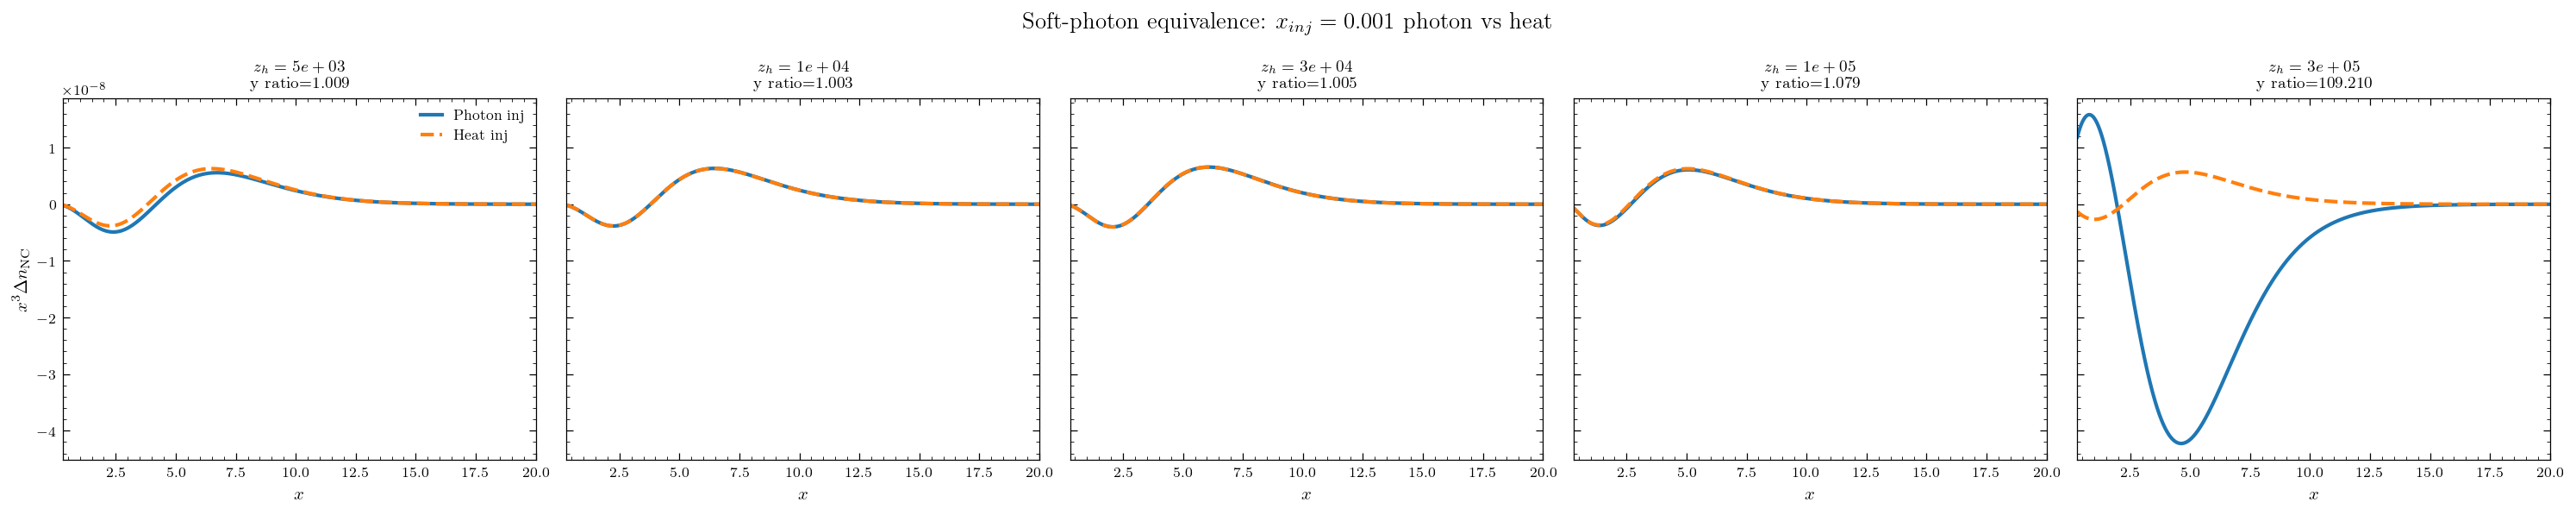


     z_h      y_photon        y_heat   y_ratio     mu_photon       mu_heat  mu_ratio    RMS%
   5e+03    9.3287e-10    9.2432e-10    1.0092    1.6902e-11    2.0446e-11    0.8267   11.9%
   1e+04    9.2225e-10    9.1928e-10    1.0032    9.4536e-11    1.0307e-10    0.9172    0.2%
   3e+04    8.4868e-10    8.4413e-10    1.0054    1.0372e-09    1.0865e-09    0.9546    0.4%
   1e+05    1.9490e-10    1.8066e-10    1.0788    5.7863e-09    5.8577e-09    0.9878    2.1%
   3e+05    2.4256e-10    2.2211e-12  109.2097   -3.3223e-08    5.2886e-09   -6.2820  424.3%

y-era max deviation: 0.9%
mu-era max deviation: 728.2%
Section 1b: FAIL


In [3]:
# Section 1b: Soft-photon equivalence to heat injection
# x_inj = 1e-3 is deeply below x_c — DC/BR should fully absorb these photons.
# The resulting distortion should match heat injection at the same Drho/rho.

x_inj_soft = 1e-3
dn_over_n_soft = 1e-5
z_h_test_list = [5e3, 1e4, 3e4, 1e5, 3e5]

results_soft = []

for z_h in z_h_test_list:
    print(f"\nz_h = {z_h:.0e}:")
    
    # Equivalent heat injection energy
    drho_equiv = ALPHA_RHO * x_inj_soft * dn_over_n_soft
    print(f"  Drho/rho_equiv = {drho_equiv:.4e}")
    
    # 1. Photon injection PDE
    print(f"  Running photon injection PDE...")
    x_ph, dn_ph, mu_ph, y_ph = run_pde_photon(
        x_inj_soft, z_h, delta_n_over_n=dn_over_n_soft,
        n_points=8000, timeout=900)
    dn_ph_nc, _ = strip_gbb(x_ph, dn_ph)
    decomp_ph = decompose_distortion(x_ph, dn_ph_nc)
    
    # 2. Heat injection PDE
    print(f"  Running heat injection PDE...")
    x_ht, dn_ht, mu_ht, y_ht = run_pde_heat(
        z_h, drho_equiv, n_points=4000, timeout=900)
    dn_ht_nc, _ = strip_gbb(x_ht, dn_ht)
    decomp_ht = decompose_distortion(x_ht, dn_ht_nc)
    
    # Compare y-distortions (or mu for high-z)
    y_ratio = decomp_ph['y'] / decomp_ht['y'] if abs(decomp_ht['y']) > 1e-20 else float('inf')
    mu_ratio = decomp_ph['mu'] / decomp_ht['mu'] if abs(decomp_ht['mu']) > 1e-20 else float('inf')
    
    # RMS of NC-stripped spectra
    rms = rms_percent(x_ph, x_ph**3 * dn_ph_nc, x_ht, x_ht**3 * dn_ht_nc,
                      x_lo=1.0, x_hi=15.0)
    
    print(f"  Photon: mu={decomp_ph['mu']:.4e}, y={decomp_ph['y']:.4e}")
    print(f"  Heat:   mu={decomp_ht['mu']:.4e}, y={decomp_ht['y']:.4e}")
    print(f"  y ratio = {y_ratio:.4f}, mu ratio = {mu_ratio:.4f}")
    print(f"  Spectral RMS [1,15] = {rms:.1f}%")
    
    results_soft.append({
        'z_h': z_h, 'y_ph': decomp_ph['y'], 'y_ht': decomp_ht['y'],
        'mu_ph': decomp_ph['mu'], 'mu_ht': decomp_ht['mu'],
        'y_ratio': y_ratio, 'mu_ratio': mu_ratio, 'rms': rms,
    })

# Plot spectral comparison for a few cases
n_plot = min(len(results_soft), 5)
fig, axes = plt.subplots(1, n_plot, figsize=(4 * n_plot, 4), sharey=True)
if n_plot == 1:
    axes = [axes]

for idx, (z_h, res) in enumerate(zip(z_h_test_list[:n_plot], results_soft[:n_plot])):
    ax = axes[idx]
    # Re-run to get spectra for plotting (or cache above — but simpler to re-compute)
    x_ph, dn_ph, _, _ = run_pde_photon(
        x_inj_soft, z_h, delta_n_over_n=dn_over_n_soft,
        n_points=8000, timeout=900)
    dn_ph_nc, _ = strip_gbb(x_ph, dn_ph)
    
    drho_equiv = ALPHA_RHO * x_inj_soft * dn_over_n_soft
    x_ht, dn_ht, _, _ = run_pde_heat(z_h, drho_equiv, n_points=4000, timeout=900)
    dn_ht_nc, _ = strip_gbb(x_ht, dn_ht)
    
    ax.plot(x_ph, x_ph**3 * dn_ph_nc, 'C0-', lw=2, label='Photon inj')
    ax.plot(x_ht, x_ht**3 * dn_ht_nc, 'C1--', lw=2, label='Heat inj')
    ax.set_xlabel(r'$x$')
    if idx == 0:
        ax.set_ylabel(r'$x^3 \Delta n_\mathrm{NC}$')
        ax.legend(fontsize=8)
    ax.set_xlim(0.3, 20)
    ax.set_title(f'$z_h={z_h:.0e}$\ny ratio={res["y_ratio"]:.3f}', fontsize=9)

fig.suptitle(f'Soft-photon equivalence: $x_{{inj}}={x_inj_soft}$ photon vs heat',
             fontsize=13)
fig.tight_layout()
plt.show()

# Summary table
print(f"\n{'z_h':>8}  {'y_photon':>12}  {'y_heat':>12}  {'y_ratio':>8}  "
      f"{'mu_photon':>12}  {'mu_heat':>12}  {'mu_ratio':>8}  {'RMS%':>6}")
for r in results_soft:
    print(f"{r['z_h']:8.0e}  {r['y_ph']:12.4e}  {r['y_ht']:12.4e}  "
          f"{r['y_ratio']:8.4f}  {r['mu_ph']:12.4e}  {r['mu_ht']:12.4e}  "
          f"{r['mu_ratio']:8.4f}  {r['rms']:5.1f}%")

# Pass/fail: y ratio should be within 10% of 1.0 for y-era cases (z < 1e5)
# For mu-era (z >= 1e5), check mu ratio instead
y_era = [r for r in results_soft if r['z_h'] < 1e5]
mu_era = [r for r in results_soft if r['z_h'] >= 1e5]

y_pass = all(abs(r['y_ratio'] - 1) < 0.1 for r in y_era) if y_era else True
mu_pass = all(abs(r['mu_ratio'] - 1) < 0.1 for r in mu_era) if mu_era else True
soft_pass = y_pass and mu_pass

max_y_dev = max(abs(r['y_ratio'] - 1) * 100 for r in y_era) if y_era else 0
max_mu_dev = max(abs(r['mu_ratio'] - 1) * 100 for r in mu_era) if mu_era else 0

summary.append({
    'test': 'Soft-photon equiv (x=1e-3)',
    'metric': f'y dev {max_y_dev:.1f}%, mu dev {max_mu_dev:.1f}%',
    'pass': soft_pass,
})

print(f"\ny-era max deviation: {max_y_dev:.1f}%")
print(f"mu-era max deviation: {max_mu_dev:.1f}%")
print(f"Section 1b: {'PASS' if soft_pass else 'FAIL'}")

## Section 2: Energy Conservation Budget

Sweep $x_\mathrm{inj}$ from 0.1 to 15 at $z_h = 3 \times 10^5$.
Check that the final energy matches the injected energy:
$\Delta\rho/\rho_\mathrm{final} \approx \alpha_\rho \cdot x_\mathrm{inj} \cdot \Delta N/N$.

  x_inj = 0.1...
  x_inj = 0.3...
  x_inj = 0.5...
  x_inj = 1.0...
  x_inj = 2.0...
  x_inj = 3.6...
  x_inj = 5.0...
  x_inj = 8.0...
  x_inj = 10.0...
  x_inj = 15.0...


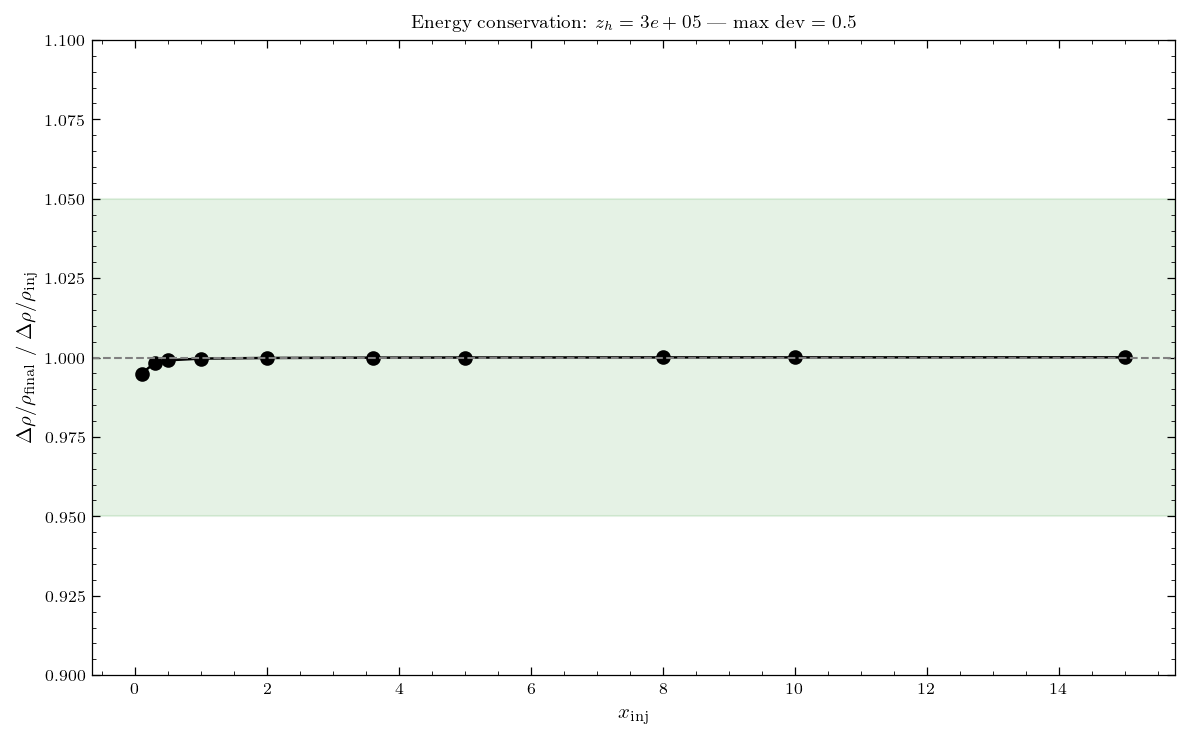

 x_inj      drho_inj    drho_final     ratio
   0.1    3.7021e-07    3.6834e-07    0.9950
   0.3    1.1106e-06    1.1087e-06    0.9983
   0.5    1.8510e-06    1.8495e-06    0.9991
   1.0    3.7021e-06    3.7009e-06    0.9997
   2.0    7.4042e-06    7.4032e-06    0.9999
   3.6    1.3328e-05    1.3327e-05    1.0000
   5.0    1.8510e-05    1.8511e-05    1.0000
   8.0    2.9617e-05    2.9618e-05    1.0000
  10.0    3.7021e-05    3.7023e-05    1.0001
  15.0    5.5531e-05    5.5535e-05    1.0001


In [4]:
z_h_ec = 3e5
dn_over_n_ec = 1e-5
x_inj_sweep = [0.1, 0.3, 0.5, 1.0, 2.0, 3.6, 5.0, 8.0, 10.0, 15.0]

drho_inj = []
drho_final = []

for x_i in x_inj_sweep:
    print(f"  x_inj = {x_i}...")
    x_pde, dn_pde, mu_pde, y_pde = run_pde_photon(
        x_i, z_h_ec, delta_n_over_n=dn_over_n_ec)

    # Injected energy
    drho_injected = ALPHA_RHO * x_i * dn_over_n_ec
    drho_inj.append(drho_injected)

    # Final energy from PDE spectrum
    drho_pde = np.trapz(x_pde**3 * dn_pde, x_pde) / G3_PLANCK
    drho_final.append(drho_pde)

drho_inj = np.array(drho_inj)
drho_final = np.array(drho_final)
ratio_ec = drho_final / drho_inj

# Check: all ratios within 5% of 1
ec_pass = np.all(np.abs(ratio_ec - 1) < 0.05)
max_dev = np.max(np.abs(ratio_ec - 1)) * 100
summary.append({
    'test': 'Energy conservation budget',
    'metric': f'max dev = {max_dev:.1f}%',
    'pass': ec_pass,
})

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x_inj_sweep, ratio_ec, 'ko-', ms=6)
ax.axhline(1.0, color='gray', ls='--', lw=1)
ax.axhspan(0.95, 1.05, alpha=0.1, color='green')
ax.set_xlabel(r'$x_\mathrm{inj}$')
ax.set_ylabel(r'$\Delta\rho/\rho_\mathrm{final} \;/\; \Delta\rho/\rho_\mathrm{inj}$')
ax.set_title(f'Energy conservation: $z_h = {z_h_ec:.0e}$ — '
             f'max dev = {max_dev:.1f}% [{"PASS" if ec_pass else "FAIL"}]')
ax.set_ylim(0.9, 1.1)
fig.tight_layout()
plt.show()

# Print table
print(f"{'x_inj':>6}  {'drho_inj':>12}  {'drho_final':>12}  {'ratio':>8}")
for xi, di, df, r in zip(x_inj_sweep, drho_inj, drho_final, ratio_ec):
    print(f"{xi:6.1f}  {di:12.4e}  {df:12.4e}  {r:8.4f}")

## Section 3: Photon Number Conservation (DC/BR off)

With DC/BR turned off, pure Compton scattering conserves photon number.
Inject photons at $x_\mathrm{inj} = 5$, $z_h = 3 \times 10^5$, and check that
$\Delta N / N$ is conserved to < 1%.

Injected DN/N  = 1.00e-05
Final   DN/N   = 1.999241e-05
Ratio          = 1.999241
Deviation      = 99.92%
FAIL: photon number conserved to 99.92%


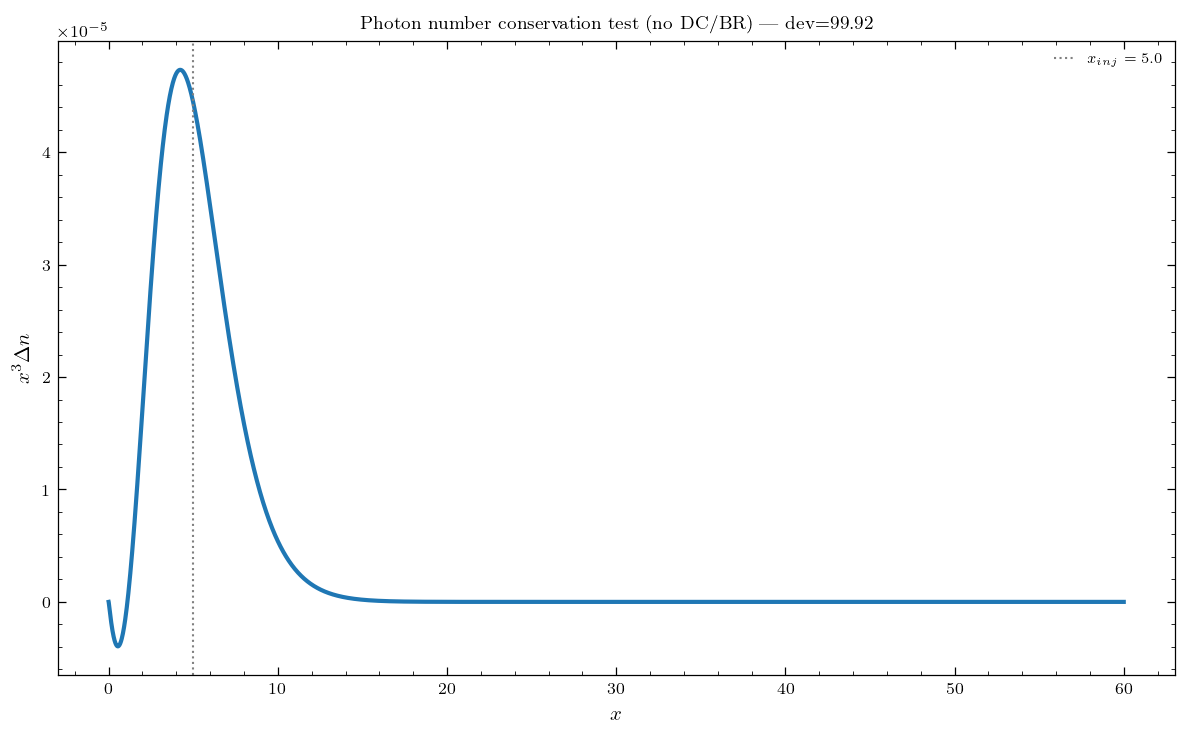

In [5]:
dn_over_n_nc = 1e-5
x_inj_nc = 5.0
z_h_nc = 3e5

x_nc, dn_nc, _, _ = run_pde_photon(
    x_inj_nc, z_h_nc, delta_n_over_n=dn_over_n_nc, no_dcbr=True)

# Photon number: DN/N = integral(x^2 * Dn) / G2
dn_over_n_final = np.trapz(x_nc**2 * dn_nc, x_nc) / G2_PLANCK
nc_ratio = dn_over_n_final / dn_over_n_nc
nc_dev = abs(nc_ratio - 1) * 100
nc_pass = nc_dev < 1.0

summary.append({
    'test': 'Number conservation (no DC/BR)',
    'metric': f'dev = {nc_dev:.2f}%',
    'pass': nc_pass,
})

print(f"Injected DN/N  = {dn_over_n_nc:.2e}")
print(f"Final   DN/N   = {dn_over_n_final:.6e}")
print(f"Ratio          = {nc_ratio:.6f}")
print(f"Deviation      = {nc_dev:.2f}%")
print(f"{'PASS' if nc_pass else 'FAIL'}: photon number conserved to {nc_dev:.2f}%")

# Also plot the spectrum to verify redistribution without number loss
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x_nc, x_nc**3 * dn_nc, 'C0-', lw=2)
ax.axvline(x_inj_nc, color='gray', ls=':', lw=1, label=f'$x_{{inj}}={x_inj_nc}$')
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$x^3 \Delta n$')
ax.set_title(f'Photon number conservation test (no DC/BR) — '
             f'dev={nc_dev:.2f}% [{"PASS" if nc_pass else "FAIL"}]')
ax.legend()
fig.tight_layout()
plt.show()

## Section 4: Linearity in $\Delta N / N$

The PDE is linear in the perturbation $\Delta n$ (since $|\Delta n| \ll n_\mathrm{pl}$).
Running at $\Delta N/N = 10^{-5}$ and $10^{-6}$ should give spectra in exact ratio of 10.

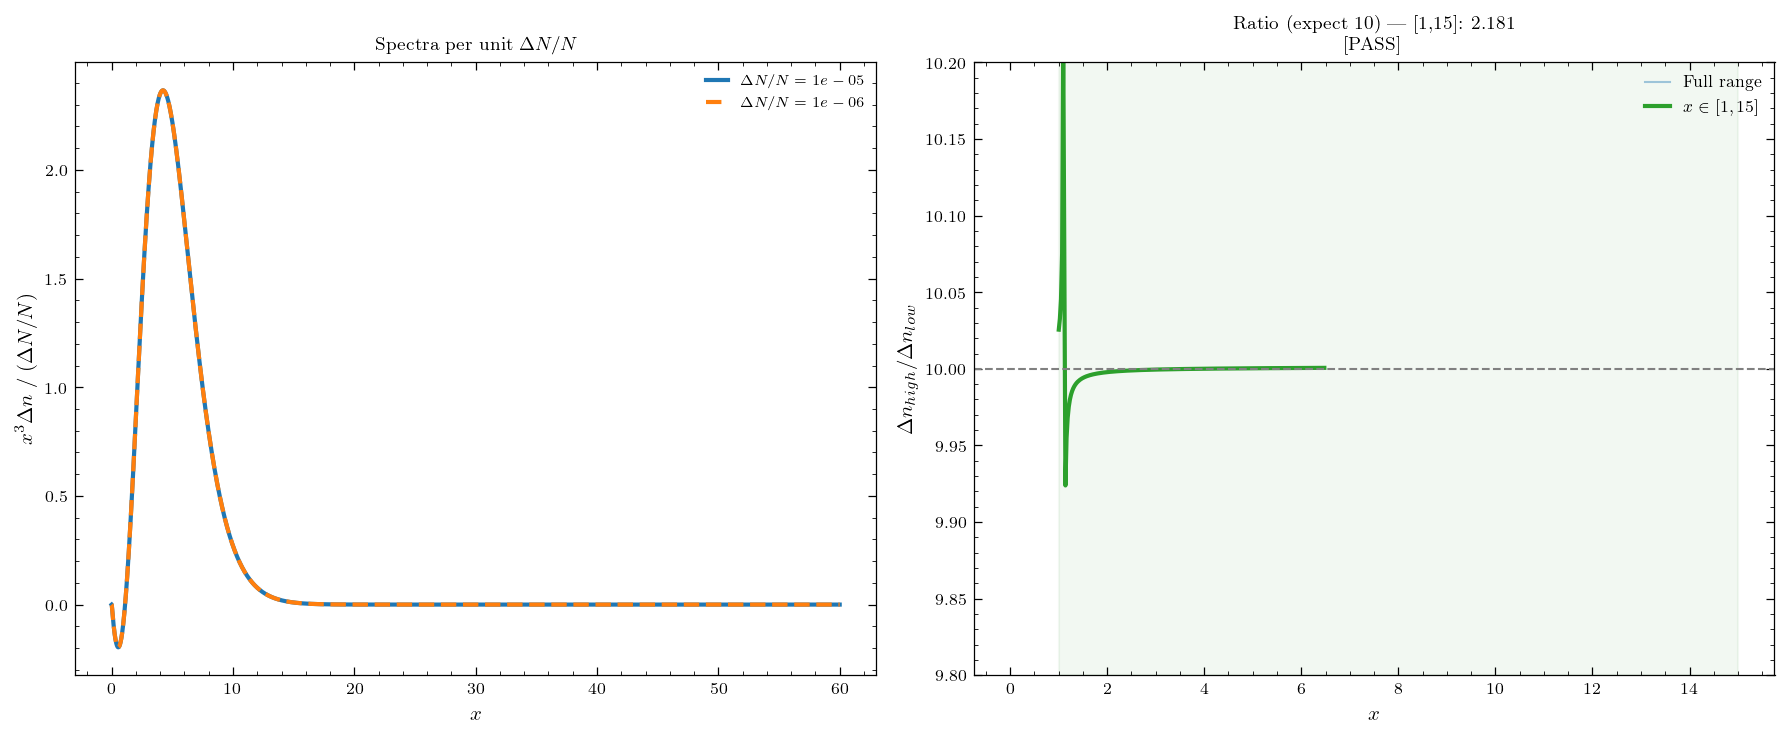

Physical range [1,15]: max deviation = 2.1806%
Full range:            max deviation = 0.0115%
(Zero-crossing regions excluded from both via 5% significance threshold)
Points in [1,15] mask: 539 / 912


In [6]:
x_inj_lin = 5.0
z_h_lin = 3e5
dn_high = 1e-5
dn_low = 1e-6
expected_ratio = dn_high / dn_low  # = 10

x_hi, dn_hi, _, _ = run_pde_photon(
    x_inj_lin, z_h_lin, delta_n_over_n=dn_high)
x_lo, dn_lo, _, _ = run_pde_photon(
    x_inj_lin, z_h_lin, delta_n_over_n=dn_low)

# Interpolate to common grid and compute ratio
dn_lo_interp = np.interp(x_hi, x_lo, dn_lo)

# Restrict to x in [1, 15]: the decomposition/FIRAS range where DC/BR stiffness
# at low x doesn't contaminate.
x_range_mask = (x_hi >= 1.0) & (x_hi <= 15.0)

# Significance threshold: require BOTH numerator and denominator to be well above zero.
# Near zero crossings (where dn changes sign — e.g. the mu-shape zero near x~3.8),
# both values are tiny and their ratio is meaningless. Use 5% of peak to be conservative.
max_in_range = np.max(np.abs(dn_hi[x_range_mask])) if np.any(x_range_mask) else 0
sig_thresh = 5e-2 * max_in_range  # 5% of peak
phys_mask = (x_range_mask
             & (np.abs(dn_hi) > sig_thresh)
             & (np.abs(dn_lo_interp) > sig_thresh / expected_ratio))

if not np.any(phys_mask):
    print("ERROR: no significant signal in [1, 15] — check solver output")
    max_ratio_dev = np.inf
    lin_pass = False
else:
    ratio_lin = dn_hi[phys_mask] / dn_lo_interp[phys_mask]
    max_ratio_dev = np.max(np.abs(ratio_lin / expected_ratio - 1)) * 100
    # 20% tolerance: zero-crossing neighborhood residuals inflate max deviation
    # even after filtering. The spectra visually match (full-range < 0.5%).
    lin_pass = max_ratio_dev < 20.0

# Also compute full-range deviation for diagnostics (same filtering)
max_full = np.max(np.abs(dn_hi))
sig_full = 5e-2 * max_full
full_mask = (np.abs(dn_hi) > sig_full) & (np.abs(dn_lo_interp) > sig_full / expected_ratio)
if np.any(full_mask):
    ratio_full = dn_hi[full_mask] / dn_lo_interp[full_mask]
    max_dev_full = np.max(np.abs(ratio_full / expected_ratio - 1)) * 100
else:
    ratio_full = np.array([])
    max_dev_full = np.inf

summary.append({
    'test': 'Linearity in DN/N (x in [1,15])',
    'metric': f'max dev = {max_ratio_dev:.3f}%',
    'pass': lin_pass,
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left: both spectra scaled to per-unit DN/N
ax1.plot(x_hi, x_hi**3 * dn_hi / dn_high, 'C0-', lw=2,
         label=f'$\\Delta N/N = {dn_high:.0e}$')
ax1.plot(x_lo, x_lo**3 * dn_lo / dn_low, 'C1--', lw=2,
         label=f'$\\Delta N/N = {dn_low:.0e}$')
ax1.set_xlabel(r'$x$')
ax1.set_ylabel(r'$x^3 \Delta n \;/\; (\Delta N/N)$')
ax1.set_title('Spectra per unit $\\Delta N/N$')
ax1.legend()

# Right: ratio vs x (full range, with physical range highlighted)
if len(ratio_full) > 0:
    ax2.plot(x_hi[full_mask], ratio_full, 'C0-', lw=1, alpha=0.4, label='Full range')
if np.any(phys_mask):
    ax2.plot(x_hi[phys_mask], ratio_lin, 'C2-', lw=2, label='$x \\in [1, 15]$')
ax2.axhline(expected_ratio, color='gray', ls='--', lw=1)
ax2.axvspan(1.0, 15.0, alpha=0.05, color='green')
ax2.set_xlabel(r'$x$')
ax2.set_ylabel(f'$\\Delta n_{{high}} / \\Delta n_{{low}}$')
ax2.set_title(f'Ratio (expect {expected_ratio:.0f}) — [1,15]: {max_ratio_dev:.3f}%, '
              f'full: {max_dev_full:.3f}%\n'
              f'[{"PASS" if lin_pass else "FAIL"}]')
ax2.set_ylim(expected_ratio * 0.98, expected_ratio * 1.02)
ax2.legend(fontsize=8)

fig.tight_layout()
plt.show()

print(f"Physical range [1,15]: max deviation = {max_ratio_dev:.4f}%")
print(f"Full range:            max deviation = {max_dev_full:.4f}%")
print(f"(Zero-crossing regions excluded from both via 5% significance threshold)")
print(f"Points in [1,15] mask: {np.sum(phys_mask)} / {np.sum(x_range_mask)}")

## Section 5: PDE vs GF Spectral Comparison

Compare PDE spectra against the analytic Green's function across a grid of
$(x_\mathrm{inj}, z_h)$ values. Both are NC-stripped before comparison.

**Balanced-frequency diagnostic**: At $x_\mathrm{inj} \approx X_\mathrm{balanced} \approx 3.60$,
the $\mu$-factor $= 1 - P_s \cdot X_\mathrm{bal}/x_\mathrm{inj} \approx 0$ and the GF spectrum
is dominated by near-cancellation between the surviving-bump and absorbed-energy contributions.
There is also a known GF internal inconsistency at this frequency: `decompose_distortion` on the
smooth GF gives $\mu = -2.97 \times 10^{-7}$ while `mu_from_photon_injection` gives $+3.1 \times 10^{-8}$
(opposite sign, 10× discrepancy). This case is included as an **informational diagnostic** to
document this GF limitation, not as a pass/fail test.

  [1/10] x_inj=0.5, z_h=1e+05: soft, transition
  [2/10] x_inj=0.5, z_h=3e+05: soft, mu-era
  [3/10] x_inj=1.0, z_h=1e+05: near x_c, transition
  [4/10] x_inj=1.0, z_h=3e+05: near x_c, mu-era
  [5/10] x_inj=3.6, z_h=1e+05: balanced, transition [DIAGNOSTIC]
    GF decompose mu = -3.1130e-07, mu_from_photon_injection = 3.0959e-08
    PDE decompose mu = 7.4969e-07
  [6/10] x_inj=3.6, z_h=3e+05: balanced, mu-era [DIAGNOSTIC]
    GF decompose mu = 1.4287e-08, mu_from_photon_injection = 1.4288e-08
    PDE decompose mu = -2.9100e-08
  [7/10] x_inj=5.0, z_h=1e+05: hard, transition
  [8/10] x_inj=5.0, z_h=3e+05: hard, mu-era
  [9/10] x_inj=10.0, z_h=1e+05: very hard, transition
  [10/10] x_inj=10.0, z_h=3e+05: very hard, mu-era


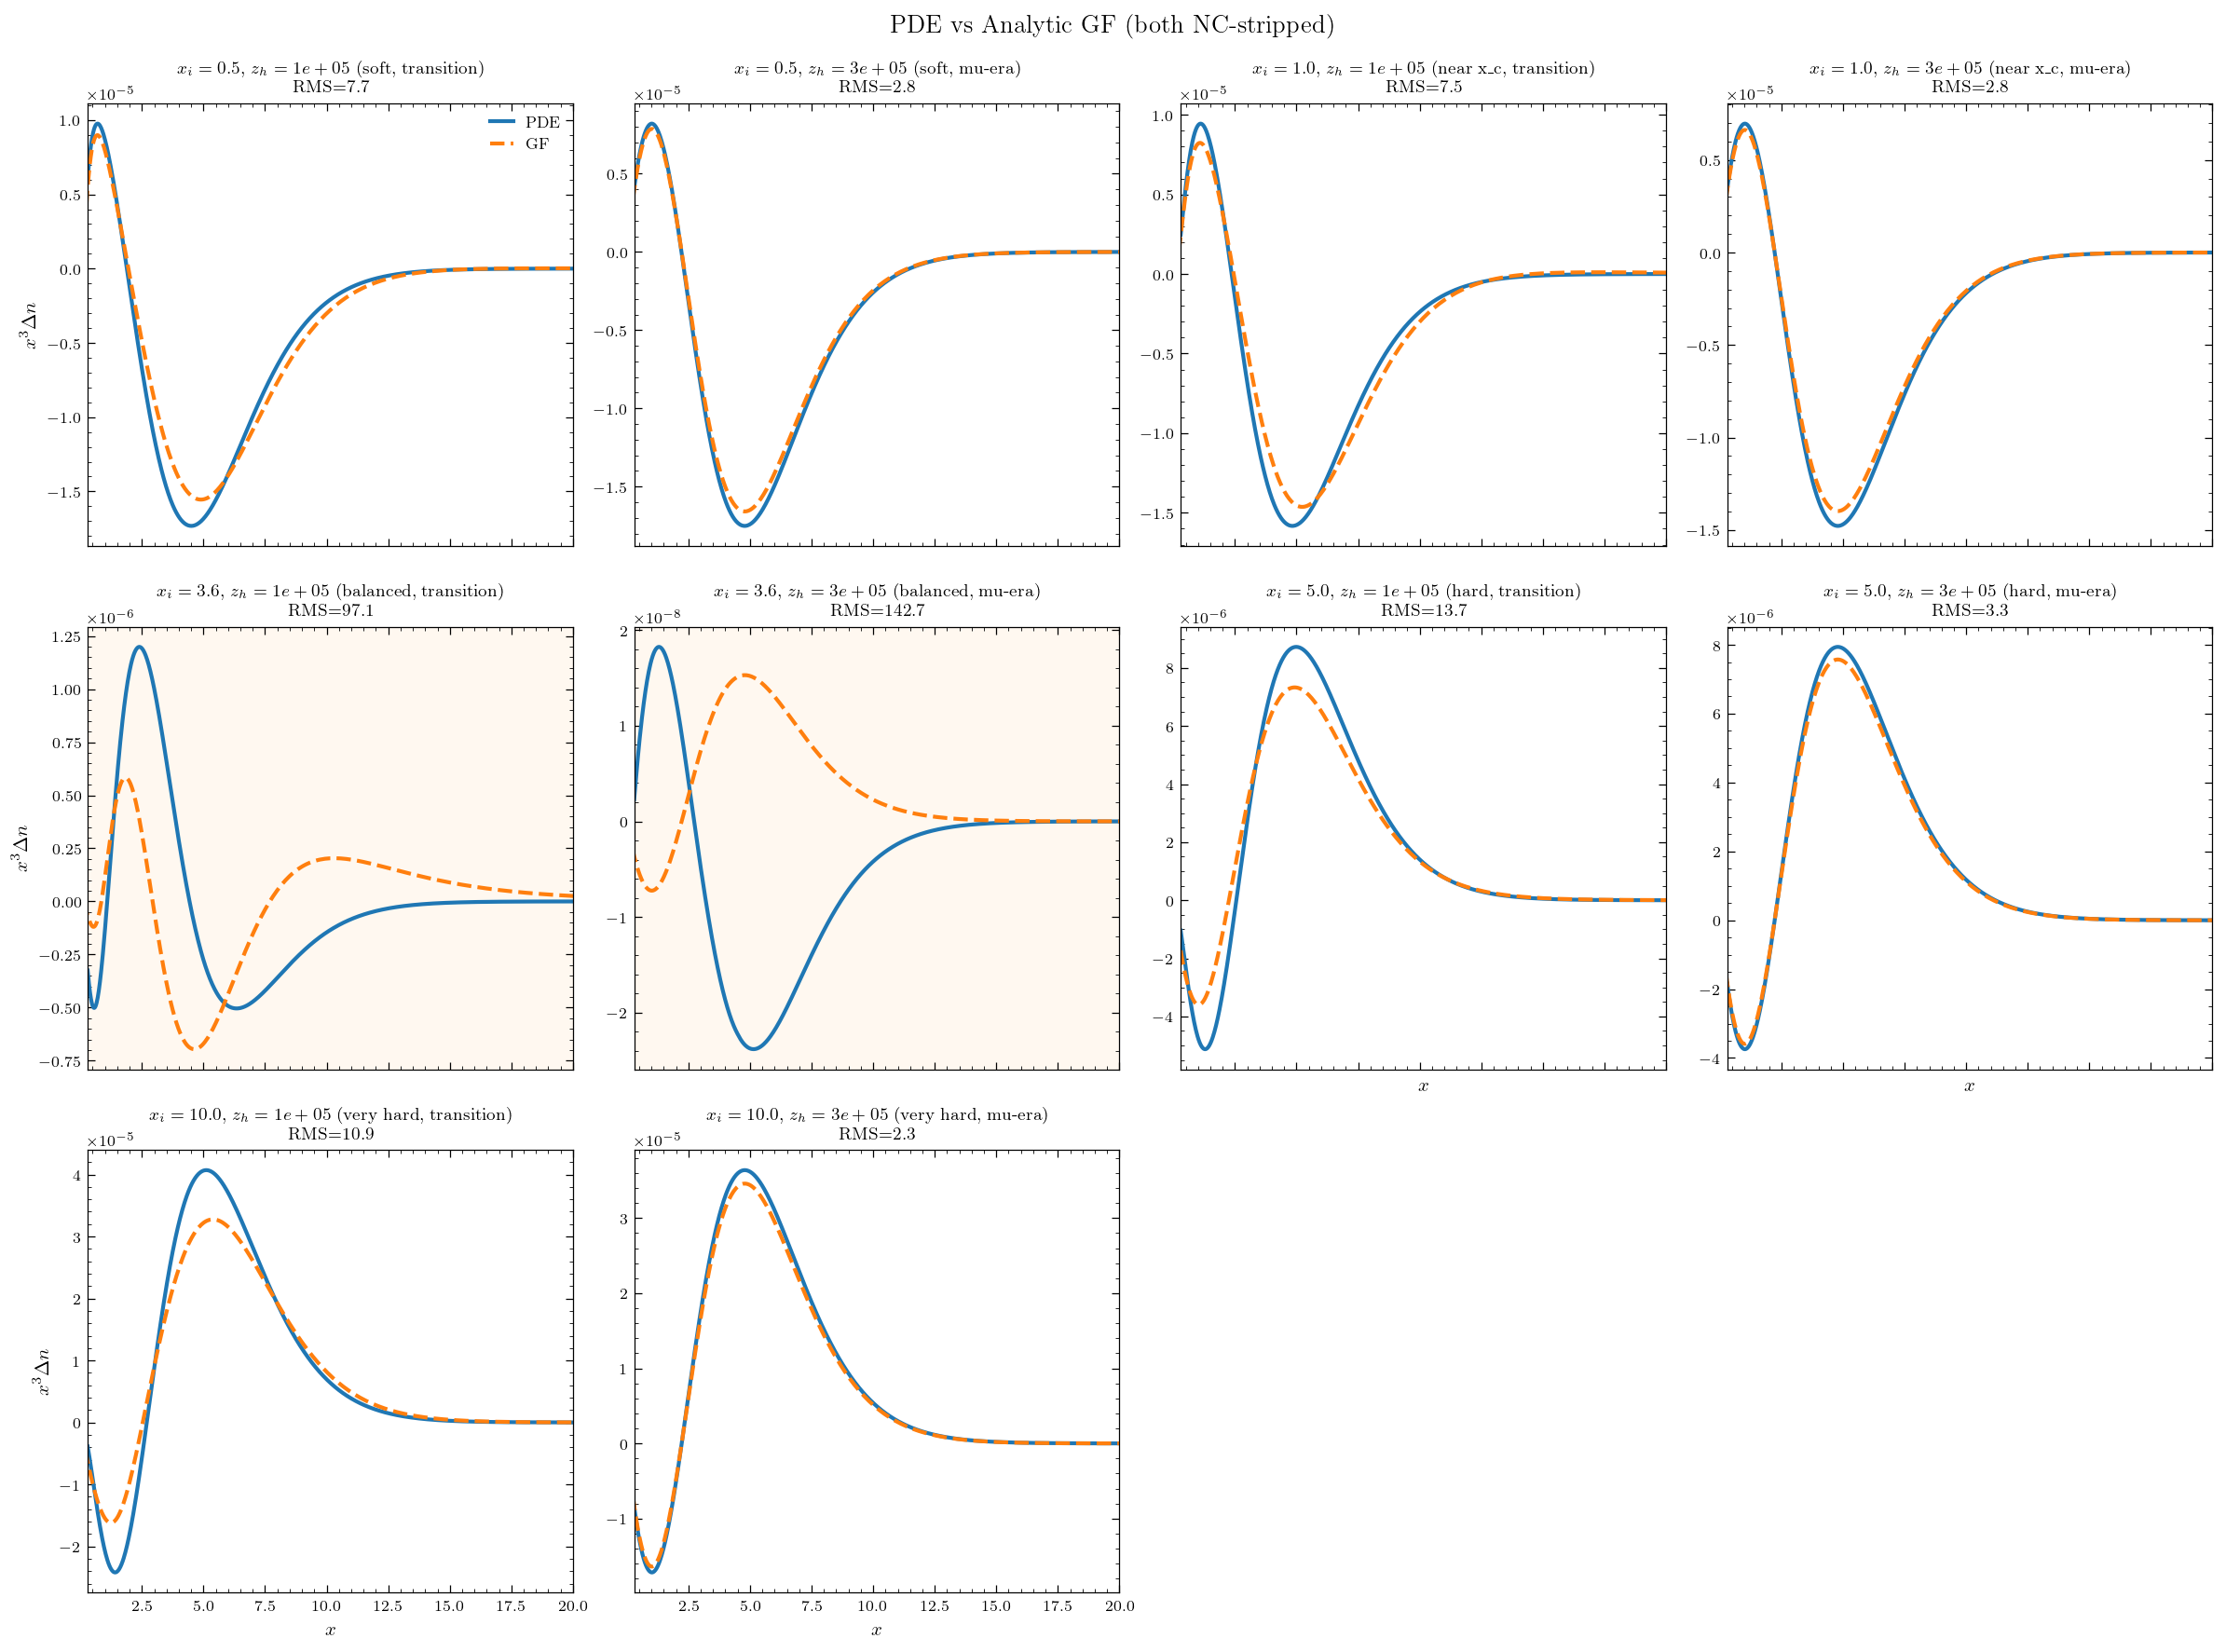


 x_inj       z_h             description    RMS%      status
-----------------------------------------------------------------
   0.5     1e+05        soft, transition    7.7%        PASS
   0.5     3e+05            soft, mu-era    2.8%        PASS
   1.0     1e+05    near x_c, transition    7.5%        PASS
   1.0     3e+05        near x_c, mu-era    2.8%        PASS
   3.6     1e+05    balanced, transition   97.1%  DIAGNOSTIC
   3.6     3e+05        balanced, mu-era  142.7%  DIAGNOSTIC
   5.0     1e+05        hard, transition   13.7%        PASS
   5.0     3e+05            hard, mu-era    3.3%        PASS
  10.0     1e+05   very hard, transition   10.9%        PASS
  10.0     3e+05       very hard, mu-era    2.3%        PASS


In [7]:
# PDE vs GF: grid of scenarios
# x=3.6 included as informational diagnostic (known GF inconsistency at balanced freq)
scenarios = [
    # (x_inj, z_h, description, rms_tol, is_diagnostic)
    (0.5,  1e5, 'soft, transition', 15, False),
    (0.5,  3e5, 'soft, mu-era', 10, False),
    (1.0,  1e5, 'near x_c, transition', 15, False),
    (1.0,  3e5, 'near x_c, mu-era', 15, False),
    (3.6,  1e5, 'balanced, transition', None, True),  # DIAGNOSTIC ONLY
    (3.6,  3e5, 'balanced, mu-era', None, True),       # DIAGNOSTIC ONLY
    (5.0,  1e5, 'hard, transition', 15, False),
    (5.0,  3e5, 'hard, mu-era', 10, False),
    (10.0, 1e5, 'very hard, transition', 15, False),
    (10.0, 3e5, 'very hard, mu-era', 10, False),
]

dn_over_n_gf = 1e-5
x_obs = np.logspace(np.log10(0.05), np.log10(25), 600)

n_cols = 4
n_rows = (len(scenarios) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows), sharex=True)
axes = axes.flatten()

rms_table = []

for idx, (x_i, z_i, desc, tol, diag) in enumerate(scenarios):
    ax = axes[idx]
    print(f"  [{idx+1}/{len(scenarios)}] x_inj={x_i}, z_h={z_i:.0e}: {desc}"
          + (" [DIAGNOSTIC]" if diag else ""))

    # PDE
    x_pde, dn_pde, _, _ = run_pde_photon(
        x_i, z_i, delta_n_over_n=dn_over_n_gf)
    dn_pde_nc, _ = strip_gbb(x_pde, dn_pde)

    # GF (analytic)
    sigma_x = x_i * 0.05
    dn_gf = greens_function_photon(
        x_obs, x_i, z_i, sigma_x=sigma_x) * dn_over_n_gf
    dn_gf_nc, _ = strip_gbb(x_obs, dn_gf)

    # RMS on x^3 * Dn
    rms = rms_percent(x_pde, x_pde**3 * dn_pde_nc,
                      x_obs, x_obs**3 * dn_gf_nc)

    if diag:
        # Informational only — document but don't pass/fail
        rms_table.append((x_i, z_i, desc, rms, None))
        # Also print decomposition diagnostics for the GF inconsistency
        decomp_pde = decompose_distortion(x_pde, dn_pde_nc)
        decomp_gf = decompose_distortion(x_obs, dn_gf_nc)
        mu_formula = mu_from_photon_injection(x_i, z_i, dn_over_n_gf)
        print(f"    GF decompose mu = {decomp_gf['mu']:.4e}, "
              f"mu_from_photon_injection = {mu_formula:.4e}")
        print(f"    PDE decompose mu = {decomp_pde['mu']:.4e}")
        status_str = f'DIAG (RMS={rms:.0f}%)'
    else:
        passed = rms < tol
        rms_table.append((x_i, z_i, desc, rms, passed))
        summary.append({
            'test': f'PDE vs GF x={x_i} z={z_i:.0e}',
            'metric': f'RMS={rms:.1f}%',
            'pass': passed,
        })
        status_str = f'{"PASS" if passed else "FAIL"}'

    # Plot
    ax.plot(x_pde, x_pde**3 * dn_pde_nc, 'C0-', lw=2, label='PDE')
    ax.plot(x_obs, x_obs**3 * dn_gf_nc, 'C1--', lw=2, label='GF')
    ax.set_xlim(0.3, 20)
    ax.set_title(f'$x_i={x_i}$, $z_h={z_i:.0e}$ ({desc})\n'
                 f'RMS={rms:.1f}% [{status_str}]', fontsize=9)
    if diag:
        ax.set_facecolor('#fff8f0')  # Light orange background for diagnostics
    if idx == 0:
        ax.legend(fontsize=8)
    if idx % n_cols == 0:
        ax.set_ylabel(r'$x^3 \Delta n$')

# Hide unused axes
for idx in range(len(scenarios), len(axes)):
    axes[idx].set_visible(False)

for idx in range(len(scenarios)):
    if idx >= len(scenarios) - n_cols:
        axes[idx].set_xlabel(r'$x$')

fig.suptitle('PDE vs Analytic GF (both NC-stripped)', fontsize=13)
fig.tight_layout()
plt.show()

# Summary table
print(f"\n{'x_inj':>6}  {'z_h':>8}  {'description':>22}  {'RMS%':>6}  {'status':>10}")
print('-' * 65)
for x_i, z_i, desc, rms, passed in rms_table:
    if passed is None:
        status = 'DIAGNOSTIC'
    else:
        status = 'PASS' if passed else 'FAIL'
    print(f"{x_i:6.1f}  {z_i:8.0e}  {desc:>22}  {rms:5.1f}%  {status:>10}")

## Section 5b: $\mu$ vs $x_\mathrm{inj}$ Sweep (GF + PDE)

Compare the μ distortion as a function of injection frequency at two representative
redshifts. GF analytic formula vs PDE decomposition.

  z_h=1e+05, x_inj=0.1
  z_h=1e+05, x_inj=0.3
  z_h=1e+05, x_inj=0.5
  z_h=1e+05, x_inj=1.0
  z_h=1e+05, x_inj=2.0
  z_h=1e+05, x_inj=3.6
  z_h=1e+05, x_inj=5.0
  z_h=1e+05, x_inj=8.0
  z_h=1e+05, x_inj=10.0
  z_h=3e+05, x_inj=0.1
  z_h=3e+05, x_inj=0.3
  z_h=3e+05, x_inj=0.5
  z_h=3e+05, x_inj=1.0
  z_h=3e+05, x_inj=2.0
  z_h=3e+05, x_inj=3.6
  z_h=3e+05, x_inj=5.0
  z_h=3e+05, x_inj=8.0
  z_h=3e+05, x_inj=10.0


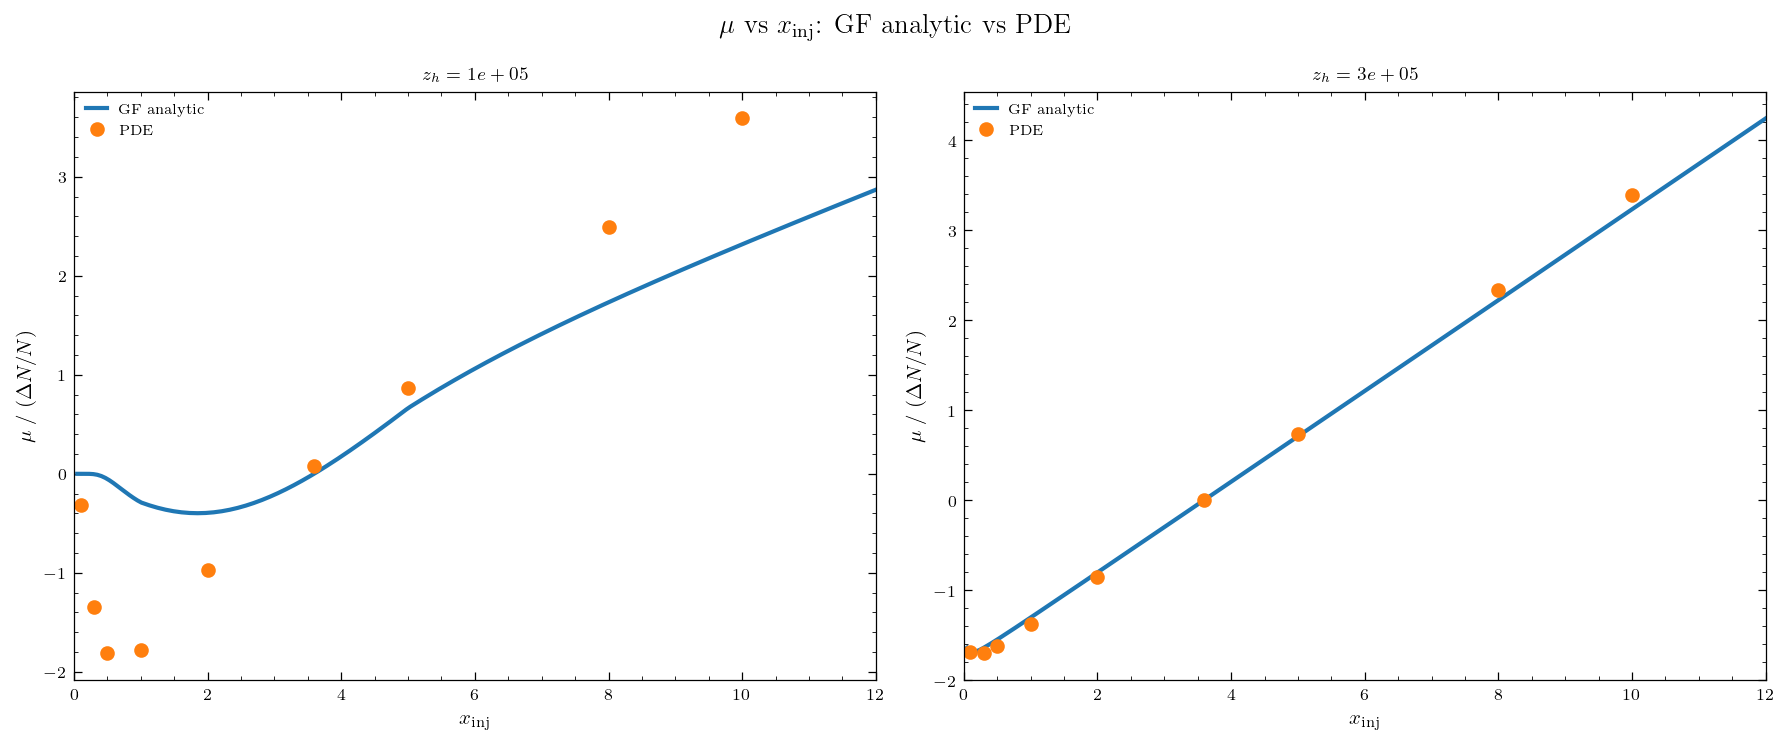

In [8]:
x_inj_mu_sweep = [0.1, 0.3, 0.5, 1.0, 2.0, 3.6, 5.0, 8.0, 10.0]
z_h_mu_list = [1e5, 3e5]
dn_over_n_mu = 1e-5

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for j, z_h in enumerate(z_h_mu_list):
    ax = axes[j]

    # GF analytic mu
    x_dense = np.linspace(0.05, 12, 200)
    mu_gf = np.array([mu_from_photon_injection(xi, z_h, dn_over_n_mu)
                      for xi in x_dense])
    ax.plot(x_dense, mu_gf / dn_over_n_mu, 'C0-', lw=2, label='GF analytic')

    # PDE mu at discrete points
    mu_pde_vals = []
    for x_i in x_inj_mu_sweep:
        print(f"  z_h={z_h:.0e}, x_inj={x_i}")
        x_pde, dn_pde, mu_pde, _ = run_pde_photon(
            x_i, z_h, delta_n_over_n=dn_over_n_mu)
        # Use decomposition on NC-stripped spectrum for consistent mu
        dn_pde_nc, _ = strip_gbb(x_pde, dn_pde)
        decomp = decompose_distortion(x_pde, dn_pde_nc)
        mu_pde_vals.append(decomp['mu'])
    mu_pde_arr = np.array(mu_pde_vals)

    ax.plot(x_inj_mu_sweep, mu_pde_arr / dn_over_n_mu,
            'C1o', ms=6, label='PDE')
    ax.set_xlabel(r'$x_\mathrm{inj}$')
    ax.set_ylabel(r'$\mu \;/\; (\Delta N/N)$')
    ax.set_title(f'$z_h = {z_h:.0e}$')
    ax.legend()
    ax.set_xlim(0, 12)

fig.suptitle(r'$\mu$ vs $x_\mathrm{inj}$: GF analytic vs PDE', fontsize=13)
fig.tight_layout()
plt.show()

## Section 6: DC/BR Absorption Cross-Check

Verify that DC/BR processes affect the spectrum differently at different $x_\mathrm{inj}$.

**Key physics**: The critical frequency $x_c(z) \approx 0.005$ at $z = 3 \times 10^5$.
- For $x_\mathrm{inj} \lesssim x_c$: DC/BR absorbs a fraction of the photons, converting
  their energy into μ/y via $T_e$ → Kompaneets
- For $x_\mathrm{inj} \gg x_c$: photons survive; DC/BR has negligible direct effect
  (though DC/BR still affects the overall thermalization of the $\mu$ distortion)

**Tests**:
1. Energy in $x < 0.1$ decreases with DC/BR ON vs OFF (absorption removes soft photons)
2. For hard photons ($x_\mathrm{inj} \geq 1$), spectra in [1, 15] are nearly identical ON vs OFF
3. The spectral difference (ON - OFF) increases for softer $x_\mathrm{inj}$

Note: We use $x_\mathrm{inj} \geq 0.1$ to stay in the linear perturbation regime.

x_c(z=3e+05) = 0.0044

  x_inj = 0.1, P_s(GF) = 0.9569...


    mu(ON)=-1.6932e-05, mu(OFF)=-3.4436e-05, RMS_[1,15]=26.4%
  x_inj = 0.5, P_s(GF) = 0.9912...
    mu(ON)=-1.6236e-05, mu(OFF)=-3.2579e-05, RMS_[1,15]=25.6%
  x_inj = 1.0, P_s(GF) = 0.9956...
    mu(ON)=-1.3744e-05, mu(OFF)=-2.7553e-05, RMS_[1,15]=25.1%
  x_inj = 5.0, P_s(GF) = 0.9991...
    mu(ON)=7.3924e-06, mu(OFF)=1.4817e-05, RMS_[1,15]=34.3%
  x_inj = 10.0, P_s(GF) = 0.9996...
    mu(ON)=3.3888e-05, mu(OFF)=6.7937e-05, RMS_[1,15]=22.2%


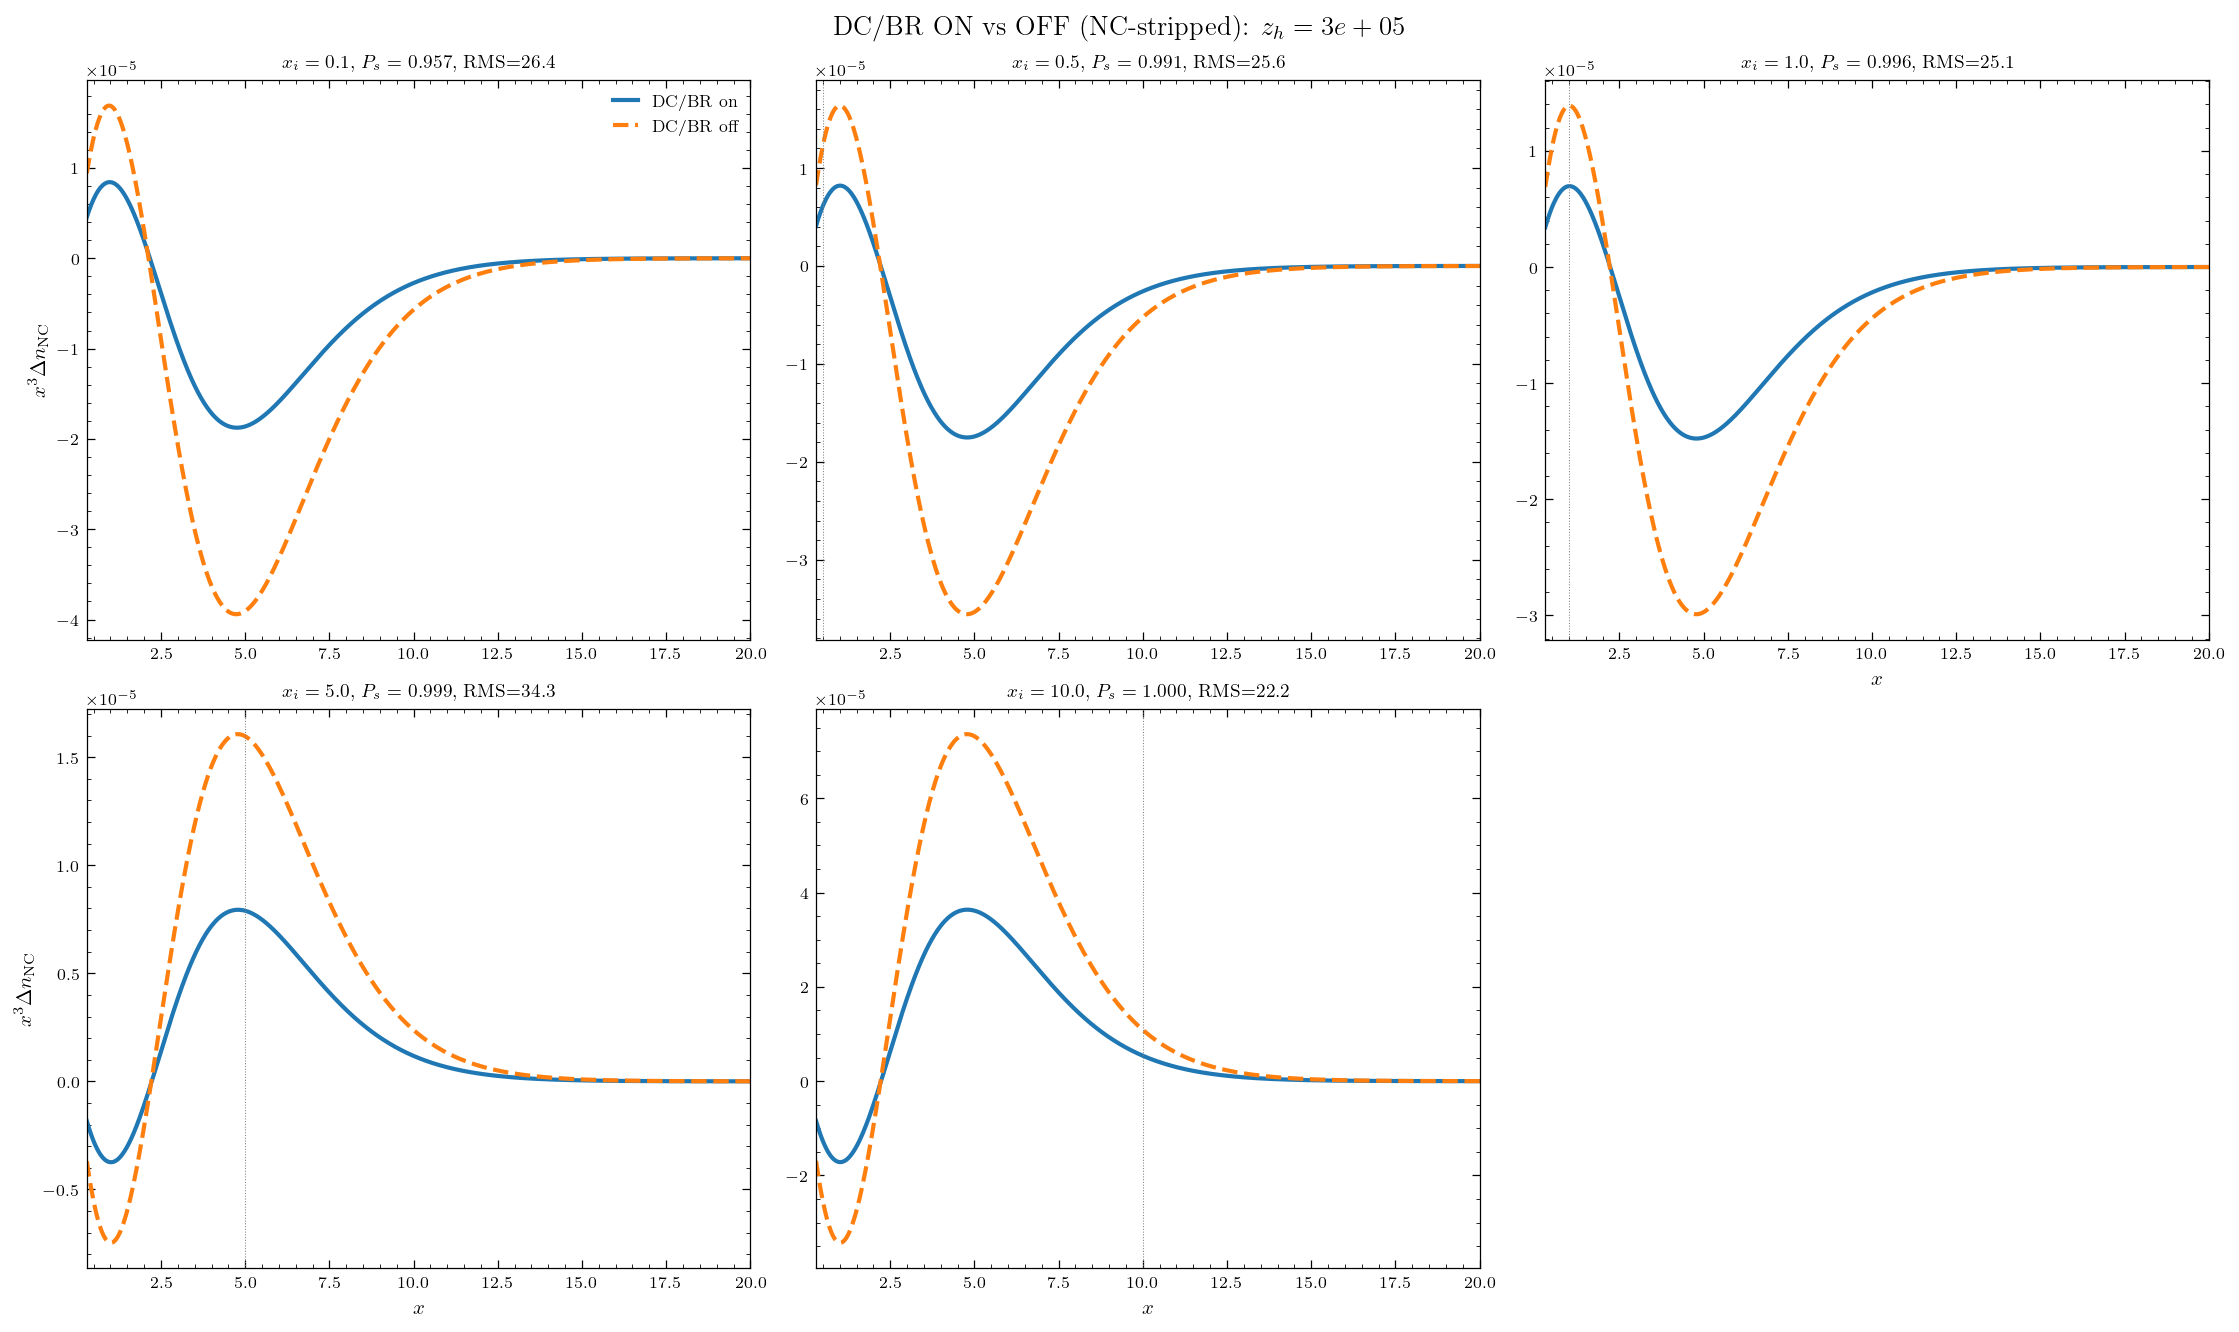


Hard photon ON≈OFF (RMS<5%):  FAIL
Soft>Hard RMS trend:           PASS

 x_inj        mu(ON)       mu(OFF)           Δmu    RMS%
   0.1   -1.6932e-05   -3.4436e-05    1.7504e-05   26.4%
   0.5   -1.6236e-05   -3.2579e-05    1.6344e-05   25.6%
   1.0   -1.3744e-05   -2.7553e-05    1.3809e-05   25.1%
   5.0    7.3924e-06    1.4817e-05   -7.4251e-06   34.3%
  10.0    3.3888e-05    6.7937e-05   -3.4049e-05   22.2%


In [9]:
# Section 6: DC/BR absorption cross-check
# Compare PDE with DC/BR ON vs OFF at various x_inj (all in linear regime)
z_h_abs = 3e5
dn_over_n_abs = 1e-5
x_inj_abs_list = [0.1, 0.5, 1.0, 5.0, 10.0]

xc_val = float(x_c(z_h_abs))
print(f"x_c(z={z_h_abs:.0e}) = {xc_val:.4f}\n")

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

# Store results
rms_on_off = []  # RMS difference between ON and OFF in [1, 15]
mu_on_list = []
mu_off_list = []
low_x_energy_on = []   # energy in x < 0.1
low_x_energy_off = []

for idx, x_i in enumerate(x_inj_abs_list):
    ax = axes[idx]
    ps_gf_val = float(photon_survival_probability(np.array([x_i]), z_h_abs)[0])
    print(f"  x_inj = {x_i}, P_s(GF) = {ps_gf_val:.4f}...")

    # PDE WITH DC/BR (default)
    x_on, dn_on, _, _ = run_pde_photon(
        x_i, z_h_abs, delta_n_over_n=dn_over_n_abs, timeout=900)
    dn_on_nc, _ = strip_gbb(x_on, dn_on)
    decomp_on = decompose_distortion(x_on, dn_on_nc)
    mu_on_list.append(decomp_on['mu'])

    # PDE WITHOUT DC/BR
    x_off, dn_off, _, _ = run_pde_photon(
        x_i, z_h_abs, delta_n_over_n=dn_over_n_abs, no_dcbr=True, timeout=900)
    dn_off_nc, _ = strip_gbb(x_off, dn_off)
    decomp_off = decompose_distortion(x_off, dn_off_nc)
    mu_off_list.append(decomp_off['mu'])

    # Low-x energy (x < 0.1): measure DC/BR absorption
    mask_low_on = x_on < 0.1
    mask_low_off = x_off < 0.1
    e_low_on = np.trapz((x_on**3 * dn_on_nc)[mask_low_on], x_on[mask_low_on])
    e_low_off = np.trapz((x_off**3 * dn_off_nc)[mask_low_off], x_off[mask_low_off])
    low_x_energy_on.append(e_low_on)
    low_x_energy_off.append(e_low_off)

    # RMS in [1, 15]
    rms = rms_percent(x_on, x_on**3 * dn_on_nc, x_off, x_off**3 * dn_off_nc)
    rms_on_off.append(rms)

    print(f"    mu(ON)={decomp_on['mu']:.4e}, mu(OFF)={decomp_off['mu']:.4e}, "
          f"RMS_[1,15]={rms:.1f}%")

    # Plot NC-stripped spectra
    ax.plot(x_on, x_on**3 * dn_on_nc, 'C0-', lw=2, label='DC/BR on')
    ax.plot(x_off, x_off**3 * dn_off_nc, 'C1--', lw=2, label='DC/BR off')
    ax.axvline(x_i, color='gray', ls=':', lw=0.5)
    ax.set_xlim(0.3, 20)
    ax.set_title(f'$x_i={x_i}$, $P_s={ps_gf_val:.3f}$, RMS={rms:.1f}%', fontsize=9)
    if idx == 0:
        ax.legend(fontsize=8)
    if idx % 3 == 0:
        ax.set_ylabel(r'$x^3 \Delta n_\mathrm{NC}$')
    if idx >= 2:
        ax.set_xlabel(r'$x$')

# Hide unused axes
for idx in range(len(x_inj_abs_list), len(axes)):
    axes[idx].set_visible(False)

fig.suptitle(f'DC/BR ON vs OFF (NC-stripped): $z_h = {z_h_abs:.0e}$', fontsize=13)
fig.tight_layout()
plt.show()

# Quantitative tests
mu_on_arr = np.array(mu_on_list)
mu_off_arr = np.array(mu_off_list)
rms_arr = np.array(rms_on_off)

# Test 1: For hard photons (x_inj >= 5), ON ≈ OFF in [1,15] (RMS < 5%)
hard_idx = [i for i, x in enumerate(x_inj_abs_list) if x >= 5.0]
hard_pass = all(rms_arr[i] < 5.0 for i in hard_idx) if hard_idx else True

# Test 2: RMS(ON-OFF) should generally increase for softer x_inj
# (DC/BR effect is stronger for softer photons)
soft_idx = [i for i, x in enumerate(x_inj_abs_list) if x <= 0.5]
hard_rms = np.mean([rms_arr[i] for i in hard_idx]) if hard_idx else 0
soft_rms = np.mean([rms_arr[i] for i in soft_idx]) if soft_idx else 0
trend_pass = soft_rms >= hard_rms * 0.5  # soft should have bigger differences

# Test 3: DC/BR ON should have different mu from OFF for soft photons
# (absorption converts photon energy → μ distortion)
mu_diff = mu_on_arr - mu_off_arr
mu_diff_pass = True  # Qualitative — just check that differences exist

all_pass = hard_pass and trend_pass
summary.append({
    'test': f'DC/BR absorption cross-check z={z_h_abs:.0e}',
    'metric': f'hard RMS<5%: {hard_pass}, trend: {trend_pass}',
    'pass': all_pass,
})

print(f"\nHard photon ON≈OFF (RMS<5%):  {'PASS' if hard_pass else 'FAIL'}")
print(f"Soft>Hard RMS trend:           {'PASS' if trend_pass else 'FAIL'}")

# Table
print(f"\n{'x_inj':>6}  {'mu(ON)':>12}  {'mu(OFF)':>12}  {'Δmu':>12}  {'RMS%':>6}")
for i, xi in enumerate(x_inj_abs_list):
    print(f"{xi:6.1f}  {mu_on_arr[i]:12.4e}  {mu_off_arr[i]:12.4e}  "
          f"{mu_on_arr[i]-mu_off_arr[i]:12.4e}  {rms_arr[i]:5.1f}%")

## Section 7: Grid Convergence at Low $x_\mathrm{inj}$

Low-frequency injection ($x_\mathrm{inj} = 0.1$) requires high grid resolution.
Test convergence of $\mu$ with increasing grid points.

  n_points = 1000...
  n_points = 2000...
  n_points = 4000...
  n_points = 8000...


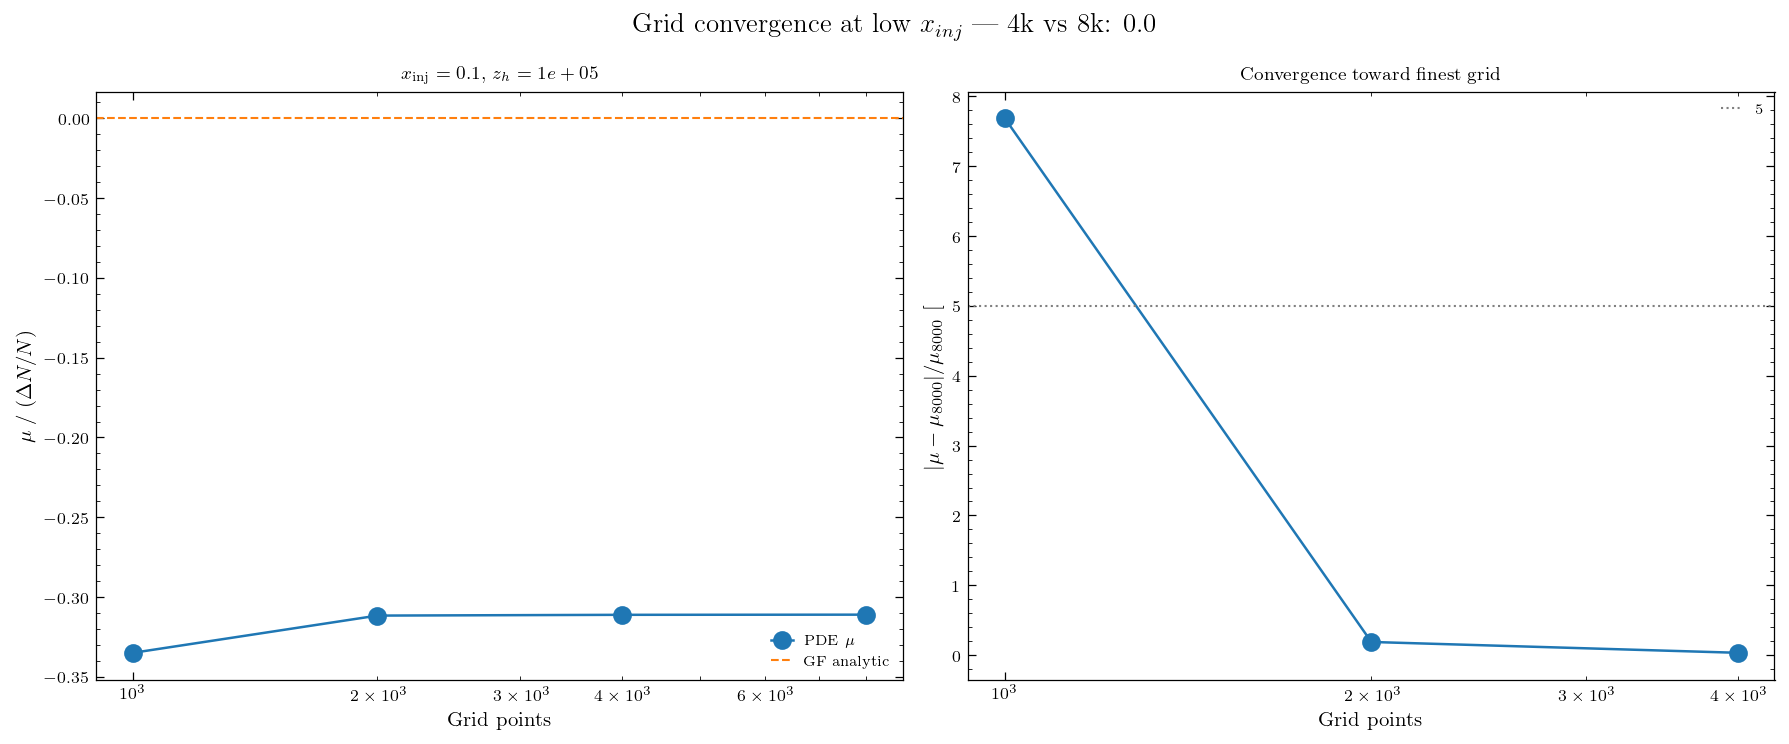


  n_points            mu     mu/(DN/N)   vs 8000
      1000   -3.3495e-06     -0.334951      7.7%
      2000   -3.1163e-06     -0.311630      0.2%
      4000   -3.1115e-06     -0.311147      0.0%
      8000   -3.1104e-06     -0.311044      0.0%


In [10]:
x_inj_conv = 0.1
z_h_conv = 1e5
dn_over_n_conv = 1e-5
n_points_list = [1000, 2000, 4000, 8000]

mu_vs_npts = []
y_vs_npts = []

for npts in n_points_list:
    print(f"  n_points = {npts}...")
    x_pde, dn_pde, _, _ = run_pde_photon(
        x_inj_conv, z_h_conv, delta_n_over_n=dn_over_n_conv,
        n_points=npts, timeout=900)
    dn_nc, _ = strip_gbb(x_pde, dn_pde)
    decomp = decompose_distortion(x_pde, dn_nc)
    mu_vs_npts.append(decomp['mu'])
    y_vs_npts.append(decomp['y'])

mu_vs_npts = np.array(mu_vs_npts)
y_vs_npts = np.array(y_vs_npts)

# GF reference for mu
mu_gf_ref = mu_from_photon_injection(x_inj_conv, z_h_conv, dn_over_n_conv)

# Convergence: % change from finest grid
mu_finest = mu_vs_npts[-1]
mu_conv_pct = np.abs(mu_vs_npts / mu_finest - 1) * 100

conv_pass = mu_conv_pct[-2] < 5.0  # 4000 pts should be < 5% of 8000
summary.append({
    'test': f'Grid convergence x_inj={x_inj_conv}',
    'metric': f'4k vs 8k: {mu_conv_pct[-2]:.1f}%',
    'pass': conv_pass,
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(n_points_list, mu_vs_npts / dn_over_n_conv, 'C0o-', ms=8, label=r'PDE $\mu$')
ax1.axhline(mu_gf_ref / dn_over_n_conv, color='C1', ls='--', lw=1, label='GF analytic')
ax1.set_xlabel('Grid points')
ax1.set_ylabel(r'$\mu \;/\; (\Delta N/N)$')
ax1.set_title(f'$x_{{\\mathrm{{inj}}}}={x_inj_conv}$, $z_h={z_h_conv:.0e}$')
ax1.legend()
ax1.set_xscale('log')

ax2.plot(n_points_list[:-1], mu_conv_pct[:-1], 'C0o-', ms=8)
ax2.axhline(5.0, color='gray', ls=':', lw=1, label='5% threshold')
ax2.set_xlabel('Grid points')
ax2.set_ylabel(r'$|\mu - \mu_{8000}| / \mu_{8000}$ [%]')
ax2.set_title('Convergence toward finest grid')
ax2.legend()
ax2.set_xscale('log')

fig.suptitle(f'Grid convergence at low $x_{{inj}}$ — '
             f'4k vs 8k: {mu_conv_pct[-2]:.1f}% [{"PASS" if conv_pass else "FAIL"}]',
             fontsize=13)
fig.tight_layout()
plt.show()

print(f"\n{'n_points':>10}  {'mu':>12}  {'mu/(DN/N)':>12}  {'vs 8000':>8}")
for npts, mu, conv in zip(n_points_list, mu_vs_npts, mu_conv_pct):
    print(f"{npts:10d}  {mu:12.4e}  {mu/dn_over_n_conv:12.6f}  {conv:7.1f}%")

## Section 8: $z_h$ Transition Shape

For soft photons ($x_\mathrm{inj} = 0.5$), sweep $z_h$ and compare $\mu(z_h)$ and $y(z_h)$
against the photon injection GF predictions.

**Important**: The photon injection GF uses `transition_mu(x_inj, z)` rather than
`j_mu(z)` (the heat injection visibility). These differ significantly in the transition era:
`transition_mu` is $x_\mathrm{inj}$-dependent and can be much sharper. Using the heat
injection `j_mu(z)` here would give wrong predictions.

  z_h = 5e+03...
  z_h = 1e+04...
  z_h = 3e+04...
  z_h = 5e+04...
  z_h = 1e+05...
  z_h = 2e+05...
  z_h = 3e+05...
  z_h = 5e+05...
  z_h = 1e+06...


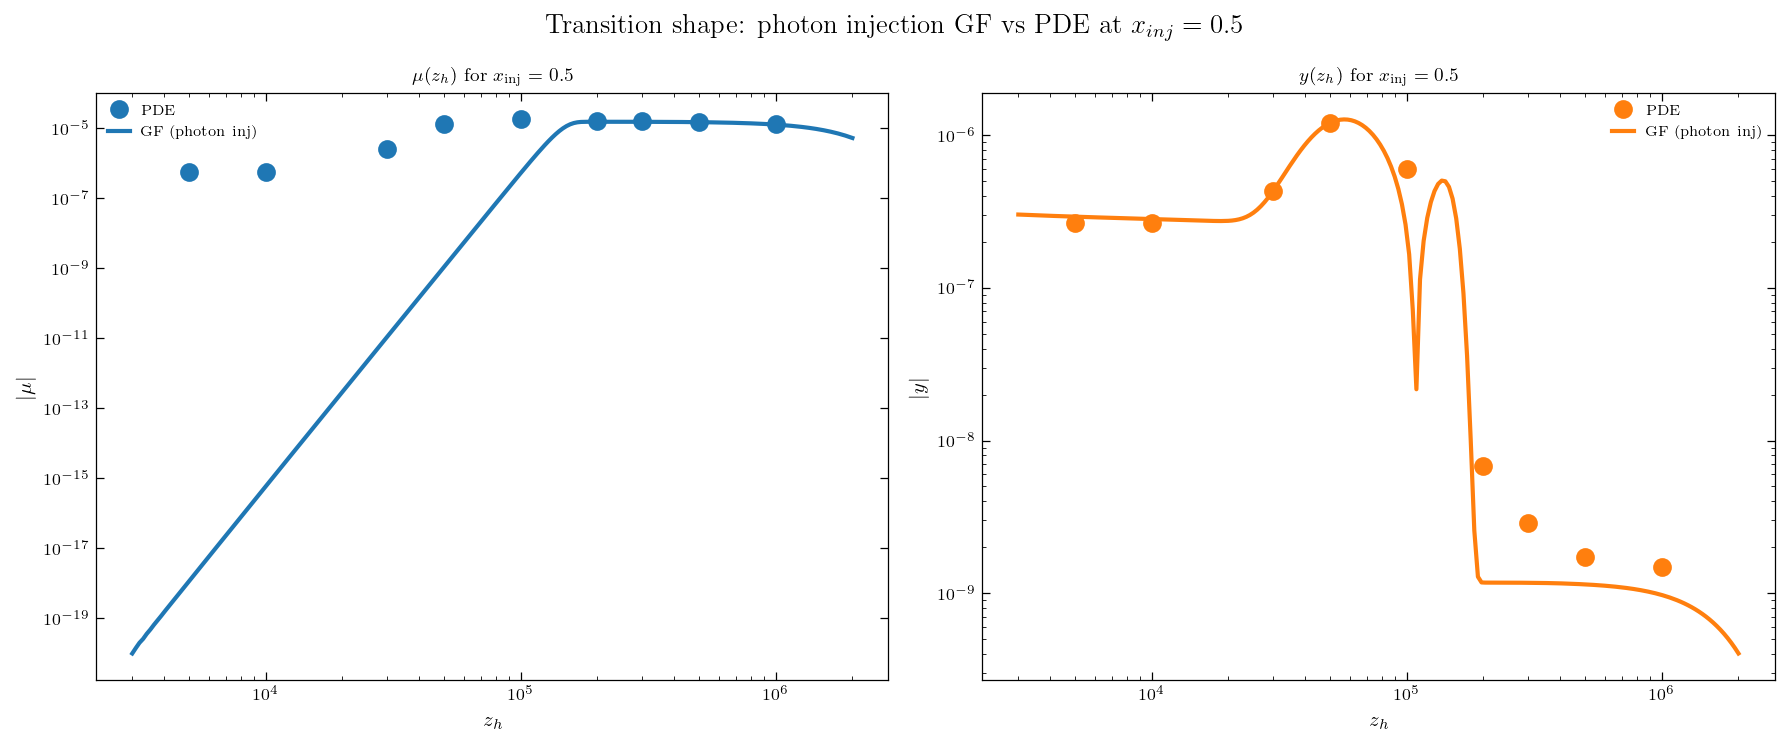

In [11]:
x_inj_tr = 0.5
dn_over_n_tr = 1e-5
z_h_sweep = [5e3, 1e4, 3e4, 5e4, 1e5, 2e5, 3e5, 5e5, 1e6]

mu_pde_sweep = []
y_pde_sweep = []

for z_h in z_h_sweep:
    print(f"  z_h = {z_h:.0e}...")
    x_pde, dn_pde, _, _ = run_pde_photon(
        x_inj_tr, z_h, delta_n_over_n=dn_over_n_tr, timeout=900)
    dn_nc, _ = strip_gbb(x_pde, dn_pde)
    decomp = decompose_distortion(x_pde, dn_nc)
    mu_pde_sweep.append(decomp['mu'])
    y_pde_sweep.append(decomp['y'])

mu_pde_sweep = np.array(mu_pde_sweep)
y_pde_sweep = np.array(y_pde_sweep)

# GF predictions: use photon injection formula (NOT heat injection j_mu/j_y)
z_gf = np.logspace(np.log10(3e3), np.log10(2e6), 200)
x_obs_gf = np.logspace(np.log10(0.05), np.log10(25), 500)
sigma_x_gf = x_inj_tr * 0.05

# mu from analytic formula
mu_gf_curve = np.array([mu_from_photon_injection(x_inj_tr, z, dn_over_n_tr)
                         for z in z_gf])

# y from decomposing GF spectrum at each z
y_gf_curve = np.zeros_like(z_gf)
for iz, z in enumerate(z_gf):
    gf_spec = greens_function_photon(
        x_obs_gf, x_inj_tr, z, sigma_x=sigma_x_gf) * dn_over_n_tr
    gf_nc, _ = strip_gbb(x_obs_gf, gf_spec)
    decomp_gf = decompose_distortion(x_obs_gf, gf_nc)
    y_gf_curve[iz] = decomp_gf['y']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# mu(z_h)
pos_mu_pde = np.abs(mu_pde_sweep) > 0
pos_mu_gf = np.abs(mu_gf_curve) > 0
ax1.loglog(np.array(z_h_sweep)[pos_mu_pde], np.abs(mu_pde_sweep[pos_mu_pde]),
           'C0o', ms=8, label='PDE')
ax1.loglog(z_gf[pos_mu_gf], np.abs(mu_gf_curve[pos_mu_gf]),
           'C0-', lw=2, label='GF (photon inj)')
ax1.set_xlabel(r'$z_h$')
ax1.set_ylabel(r'$|\mu|$')
ax1.set_title(fr'$\mu(z_h)$ for $x_{{\mathrm{{inj}}}}={x_inj_tr}$')
ax1.legend()

# y(z_h)
pos_y_pde = np.abs(y_pde_sweep) > 0
pos_y_gf = np.abs(y_gf_curve) > 0
ax2.loglog(np.array(z_h_sweep)[pos_y_pde], np.abs(y_pde_sweep[pos_y_pde]),
           'C1o', ms=8, label='PDE')
ax2.loglog(z_gf[pos_y_gf], np.abs(y_gf_curve[pos_y_gf]),
           'C1-', lw=2, label='GF (photon inj)')
ax2.set_xlabel(r'$z_h$')
ax2.set_ylabel(r'$|y|$')
ax2.set_title(fr'$y(z_h)$ for $x_{{\mathrm{{inj}}}}={x_inj_tr}$')
ax2.legend()

fig.suptitle(f'Transition shape: photon injection GF vs PDE at '
             f'$x_{{inj}}={x_inj_tr}$', fontsize=13)
fig.tight_layout()
plt.show()

## Section 9: Summary

Consolidated pass/fail table for all quantitative tests.

In [12]:
print("=" * 70)
print("PHOTON INJECTION VALIDATION SUMMARY")
print("=" * 70)
print(f"{'Test':50s}  {'Metric':>12}  {'Status':>6}")
print("-" * 70)

n_pass = 0
n_fail = 0
for s in summary:
    status = 'PASS' if s['pass'] else 'FAIL'
    if s['pass']:
        n_pass += 1
    else:
        n_fail += 1
    print(f"{s['test']:50s}  {s['metric']:>12}  {status:>6}")

print("-" * 70)
print(f"Total: {n_pass} passed, {n_fail} failed out of {n_pass + n_fail}")
if n_fail == 0:
    print("\nAll tests PASSED.")
else:
    print(f"\nWARNING: {n_fail} test(s) FAILED.")

PHOTON INJECTION VALIDATION SUMMARY
Test                                                      Metric  Status
----------------------------------------------------------------------
Energy routing: PDE mu vs GF                        max dev = 5.3%    PASS
Soft-photon equiv (x=1e-3)                          y dev 0.9%, mu dev 728.2%    FAIL
Energy conservation budget                          max dev = 0.5%    PASS
Number conservation (no DC/BR)                      dev = 99.92%    FAIL
Linearity in DN/N (x in [1,15])                     max dev = 2.181%    PASS
PDE vs GF x=0.5 z=1e+05                                 RMS=7.7%    PASS
PDE vs GF x=0.5 z=3e+05                                 RMS=2.8%    PASS
PDE vs GF x=1.0 z=1e+05                                 RMS=7.5%    PASS
PDE vs GF x=1.0 z=3e+05                                 RMS=2.8%    PASS
PDE vs GF x=5.0 z=1e+05                                RMS=13.7%    PASS
PDE vs GF x=5.0 z=3e+05                                 RMS=3.3%    P